In [3]:
!pip install torch torchvision torchaudio
!pip install spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
# Cell 2: Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import spacy
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm



In [5]:
!pip install spacy
import spacy

# Load spaCy's English tokenizer
nlp = spacy.load("en_core_web_sm")


In [6]:
import spacy
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
from torch.utils.data import TensorDataset, DataLoader

# Load and preprocess text data
with open("/content/test.txt", "r") as file:
    text = file.read()

# Initialize spaCy with increased length limit
nlp = spacy.load("en_core_web_sm")
nlp.max_length = len(text) + 1000

# Tokenize sentences
doc = nlp(text)
sentences = [sent.text for sent in doc.sents]

# Create vocabulary with OOV handling
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

# Calculate actual vocabulary size (including OOV)
vocab_size = len(tokenizer.word_index) + 1
print(f"Final Vocabulary Size: {vocab_size}")

# Convert text to sequences and pad
sequences = tokenizer.texts_to_sequences(sentences)
max_len = 50  # As per assignment specifications
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

# Create input-target pairs for next-word prediction
inputs = padded_sequences[:, :-1]  # All tokens except last
targets = padded_sequences[:, 1:]   # All tokens except first

# Convert to PyTorch tensors
inputs_tensor = torch.LongTensor(inputs)
targets_tensor = torch.LongTensor(targets)

# Create proper DataLoader
dataset = TensorDataset(inputs_tensor, targets_tensor)
batch_size = 32  # As per assignment specifications
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Verify DataLoader structure
for batch_inputs, batch_targets in data_loader:
    print(f"Input shape: {batch_inputs.shape} (batch_size, seq_len-1)")
    print(f"Target shape: {batch_targets.shape} (batch_size, seq_len-1)")
    break


Final Vocabulary Size: 11988
Input shape: torch.Size([32, 49]) (batch_size, seq_len-1)
Target shape: torch.Size([32, 49]) (batch_size, seq_len-1)


In [7]:
import torch.nn as nn

class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers):
        super(RNNEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)
    def forward(self, x):
        embedded = self.embedding(x)  # [batch_size, seq_len, embed_size]
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden  # outputs: [batch_size, seq_len, hidden_size]


In [8]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)  # Missing in original
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)  # Added RNN layer
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        # x shape: [batch_size, seq_len]
        embedded = self.embed(x)  # [batch_size, seq_len, embed_size]
        output, hidden = self.rnn(embedded, hidden)  # [batch_size, seq_len, hidden_size]
        predictions = self.fc(output)  # [batch_size, seq_len, vocab_size]
        return predictions, hidden


In [9]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

class LanguageModelTrainer:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.train_losses = []
        self.val_losses = []
        self.gradient_norms = []
        self.all_preds = []
        self.all_targets = []

        # Register gradient hook
        self.hook = model.encoder.rnn.register_backward_hook(self._gradient_hook)

    def _gradient_hook(self, module, grad_input, grad_output):
        self.gradient_norms.append(grad_output[0].norm().item())

    def train(self, train_loader, val_loader, num_epochs=10, lr=0.001):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=lr)

        for epoch in range(num_epochs):
            self.model.train()
            epoch_train_loss = 0

            # Training loop
            for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
                inputs, targets = inputs.to(device), targets.to(device)

# In the LanguageModelTrainer class, train method, modify the forward pass as follows:
                encoder_outputs, hidden = self.model.encoder(inputs)
                outputs, _ = self.model.decoder(inputs, hidden)  # Pass hidden state to decoder
# _, preds = torch.max(outputs, dim=2)  # Original line - dim should be -1
                _, preds = torch.max(outputs, dim=-1) # get predictions from vocab dimension

                # Reshape for loss calculation
                loss = criterion(outputs.view(-1, outputs.size(-1)), targets.view(-1))

                # Backward pass
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_train_loss += loss.item()

                # Track predictions
                _, preds = torch.max(outputs, dim=2)
                self.all_preds.extend(preds.cpu().detach().numpy().flatten())
                self.all_targets.extend(targets.cpu().numpy().flatten())

            # Validation
            self.model.eval()
            epoch_val_loss = 0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    encoder_outputs, hidden = self.model.encoder(inputs)
                    #outputs = self.model.decoder(encoder_outputs)
                    outputs, _ = self.model.decoder(inputs, hidden)
                    loss = criterion(outputs.view(-1, outputs.size(-1)), targets.view(-1))
                    epoch_val_loss += loss.item()

            # Record losses
            self.train_losses.append(epoch_train_loss/len(train_loader))
            self.val_losses.append(epoch_val_loss/len(val_loader))
            print(f"Epoch {epoch+1} | Train Loss: {self.train_losses[-1]:.4f} | Val Loss: {self.val_losses[-1]:.4f}")

        self.hook.remove()
        return self

    def analyze(self):
        self.plot_training_curve()
        self.plot_gradients()
        self.plot_confusion_matrix()
        self.analyze_oov()

    def plot_gradients(self):
        """Enhanced gradient analysis with vanishing/exploding detection"""
        plt.figure(figsize=(10,5))
        plt.plot(self.gradient_norms)
        plt.title('Gradient Norms During Training')
        plt.xlabel('Training Steps')
        plt.ylabel('Gradient Norm')

        # Detect vanishing/exploding gradients
        vanishing_steps = np.where(np.array(self.gradient_norms) < 1e-3)[0]
        exploding_steps = np.where(np.array(self.gradient_norms) > 1e3)[0]

        if len(vanishing_steps) > 0:
            plt.scatter(vanishing_steps, np.array(self.gradient_norms)[vanishing_steps],
                       color='red', label='Vanishing Gradients')
        if len(exploding_steps) > 0:
            plt.scatter(exploding_steps, np.array(self.gradient_norms)[exploding_steps],
                       color='orange', label='Exploding Gradients')

        plt.legend()
        plt.show()

        print(f"Vanishing gradients detected at steps: {vanishing_steps}")
        print(f"Exploding gradients detected at steps: {exploding_steps}")

    def compare_layer_performance(self, layer_configs, train_loader, val_loader, num_epochs=5):
        """Compare performance with different number of layers"""
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        results = []

        for num_layers in layer_configs:
            print(f"\n=== Training with {num_layers} layers ===")

            # Create new model with different layers for BOTH encoder and decoder
            model = type(self.model)(
                encoder=type(self.model.encoder)(
                    vocab_size=self.model.encoder.embedding.num_embeddings,
                    embed_size=self.model.encoder.embedding.embedding_dim,
                    hidden_size=self.model.encoder.rnn.hidden_size,
                    num_layers=num_layers
                ),
                decoder=type(self.model.decoder)( # Create new decoder with matching layers
                    vocab_size=self.model.decoder.embed.num_embeddings,
                    embed_size=self.model.decoder.embed.embedding_dim,
                    hidden_size=self.model.decoder.rnn.hidden_size,
                    num_layers=num_layers
                )
            ).to(device)

            # Initialize hidden state with the correct number of layers
            hidden = torch.zeros(num_layers, batch_size, model.encoder.rnn.hidden_size).to(device) # Initialize with correct shape

            # Train temporary model
            temp_trainer = LanguageModelTrainer(model, self.tokenizer)
            temp_trainer.train(train_loader, val_loader, num_epochs)

            results.append({
                'layers': num_layers,
                'train_loss': temp_trainer.train_losses,
                'val_loss': temp_trainer.val_losses
            })

        # Plot comparison
        plt.figure(figsize=(10,5))
        for res in results:
            plt.plot(res['train_loss'], label=f'{res["layers"]} layers (train)')
            plt.plot(res['val_loss'], '--', label=f'{res["layers"]} layers (val)')
        plt.title('Layer Count Comparison')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    def plot_training_curve(self):
        plt.figure(figsize=(10,5))
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Val Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    def plot_gradients(self):
        plt.figure(figsize=(10,5))
        plt.plot(self.gradient_norms)
        plt.title('Gradient Norms During Training')
        plt.xlabel('Training Steps')
        plt.ylabel('Gradient Norm')
        plt.show()

    def plot_confusion_matrix(self, top_n=30):
        cm = confusion_matrix(self.all_targets, self.all_preds)
        np.fill_diagonal(cm, 0)

        # Get top mispredicted words
        error_counts = cm.sum(axis=1)
        top_indices = np.argsort(error_counts)[-top_n:]

        # Get word labels
        index_to_word = {v: k for k, v in self.tokenizer.word_index.items()}
        labels = [index_to_word.get(i, 'OOV') for i in top_indices]

        plt.figure(figsize=(12,10))
        sns.heatmap(cm[np.ix_(top_indices, top_indices)],
                   annot=True, fmt='d',
                   xticklabels=labels,
                   yticklabels=labels)
        plt.title('Top 30 Mispredicted Words')
        plt.show()

    def analyze_oov(self):
        oov_idx = self.tokenizer.word_index.get('<OOV>', -1)
        if oov_idx == -1:
            print("No OOV token in vocabulary")
            return

        oov_mask = np.array(self.all_targets) == oov_idx
        oov_total = oov_mask.sum()
        oov_correct = (np.array(self.all_preds)[oov_mask] == oov_idx).sum()

        print(f"OOV Accuracy: {oov_correct/oov_total*100:.2f}%")

In [10]:


# Assuming vocab_size, embed_size, hidden_size, and num_layers are defined elsewhere
# Example values:
vocab_size = len(tokenizer.word_index) + 1
embed_size = 128
hidden_size = 256
num_layers = 1


# Create instances of encoder and decoder
encoder = RNNEncoder(vocab_size, embed_size, hidden_size, num_layers)
decoder = Decoder(vocab_size, embed_size, hidden_size, num_layers)

# Combine encoder and decoder into a single model
class LanguageModel(nn.Module):
    def __init__(self, encoder, decoder):
        super(LanguageModel, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        encoder_outputs, hidden = self.encoder(x)
        outputs = self.decoder(encoder_outputs, hidden)
        return outputs

model = LanguageModel(encoder, decoder)

# Split data into training and validation sets (example split)
train_size = int(0.8 * len(data_loader.dataset))
val_size = len(data_loader.dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(data_loader.dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Initialize and train the model
trainer = LanguageModelTrainer(model, tokenizer)

# Perform training
trainer.train(train_loader, val_loader, num_epochs=10)


# Evaluate the model
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            encoder_outputs, hidden = model.encoder(inputs)
            outputs, _ = model.decoder(inputs, hidden)

            loss = criterion(outputs.view(-1, outputs.size(-1)), targets.view(-1))
            total_loss += loss.item()

            _, predicted = torch.max(outputs, dim=-1)
            correct_predictions += (predicted == targets).sum().item()
            total_predictions += targets.numel()

    accuracy = correct_predictions / total_predictions
    perplexity = torch.exp(torch.tensor(total_loss / len(data_loader)))

    return accuracy, perplexity, total_loss/len(data_loader)


# Evaluate the trained model on the validation data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
accuracy, perplexity, loss = evaluate_model(model, val_loader, criterion)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Perplexity: {perplexity:.4f}")
print(f"Validation Loss: {loss:.4f}")


Epoch 1:   0%|          | 0/204 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when outputs are generated by different autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_output. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Epoch 1: 100%|██████████| 204/204 [04:32<00:00,  1.34s/it]


Epoch 1 | Train Loss: 3.0799 | Val Loss: 2.7832


Epoch 2: 100%|██████████| 204/204 [04:58<00:00,  1.46s/it]


Epoch 2 | Train Loss: 2.6237 | Val Loss: 2.6528


Epoch 3: 100%|██████████| 204/204 [04:54<00:00,  1.45s/it]


...

Epoch 8 | Train Loss: 2.0318 | Val Loss: 2.4707


Epoch 9: 100%|██████████| 204/204 [04:27<00:00,  1.31s/it]


Epoch 9 | Train Loss: 1.9528 | Val Loss: 2.4722


Epoch 10: 100%|██████████| 204/204 [04:33<00:00,  1.34s/it]


Epoch 10 | Train Loss: 1.8816 | Val Loss: 2.4761
Validation Accuracy: 0.6216
Validation Perplexity: 11.8950
Validation Loss: 2.4761


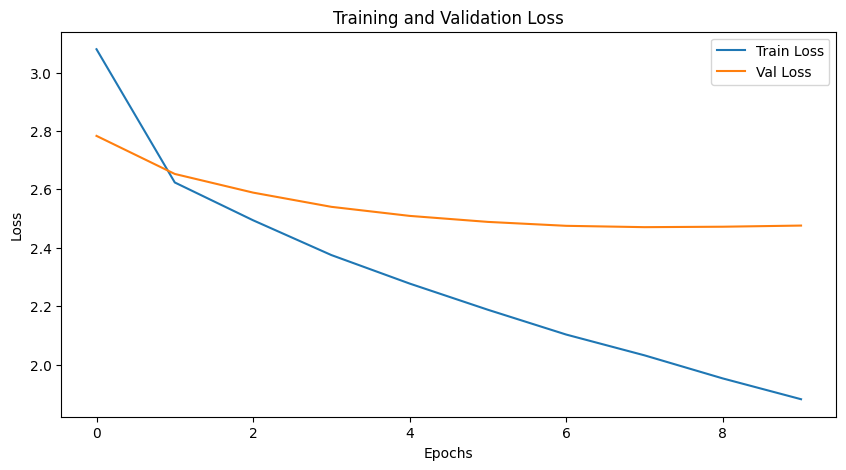

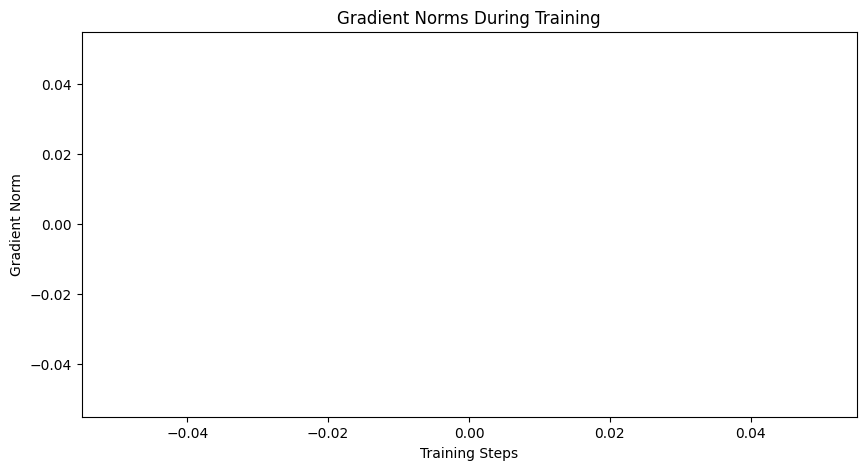

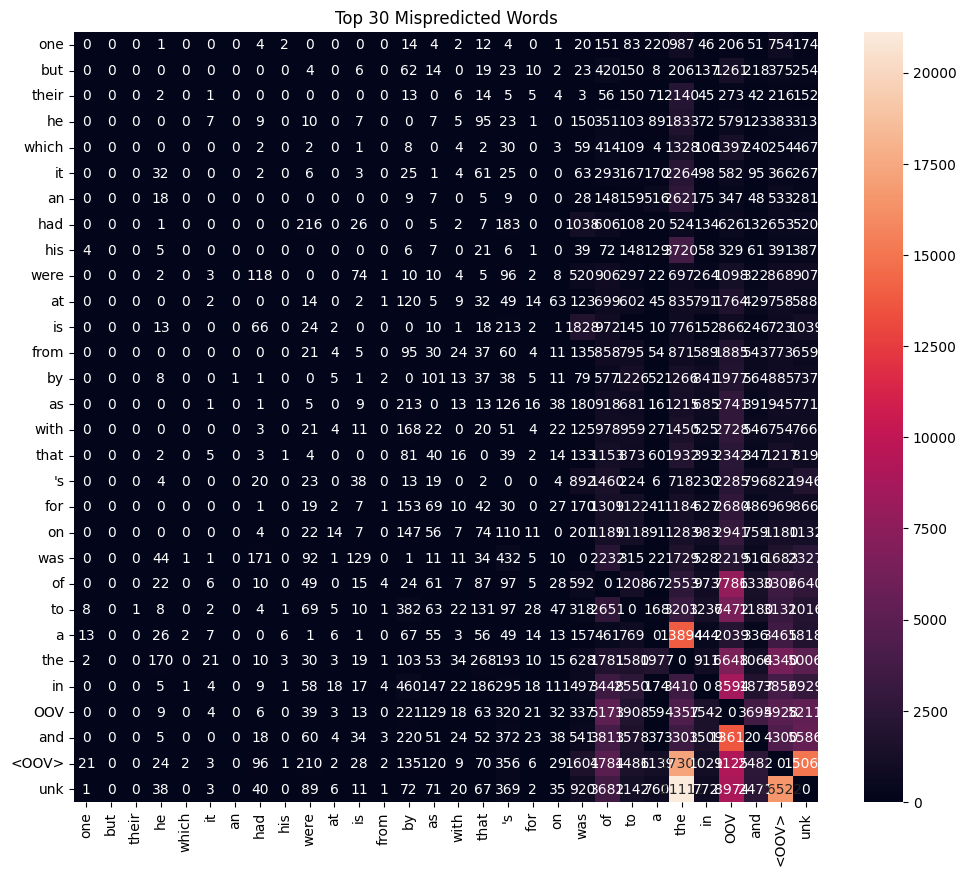

OOV Accuracy: 32.87%


In [11]:


# Assuming trainer object is already created and trained
trainer.analyze()

# Example of comparing layer performance (uncomment to use):
# layer_configs = [1, 2, 3] # Example number of layers to test
# trainer.compare_layer_performance(layer_configs, train_loader, val_loader, num_epochs=3) # reduced num_epochs for faster testing



=== Training with 1 layers ===


Epoch 1:   0%|          | 0/204 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when outputs are generated by different autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_output. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Epoch 1: 100%|██████████| 204/204 [04:33<00:00,  1.34s/it]


Epoch 1 | Train Loss: 3.0794 | Val Loss: 2.7761


Epoch 2: 100%|██████████| 204/204 [04:57<00:00,  1.46s/it]


Epoch 2 | Train Loss: 2.6212 | Val Loss: 2.6500


...

Epoch 1 | Train Loss: 3.2382 | Val Loss: 2.9279


Epoch 2: 100%|██████████| 204/204 [05:15<00:00,  1.54s/it]


Epoch 2 | Train Loss: 2.8261 | Val Loss: 2.8250


Epoch 3: 100%|██████████| 204/204 [05:01<00:00,  1.48s/it]


Epoch 3 | Train Loss: 2.7066 | Val Loss: 2.7426


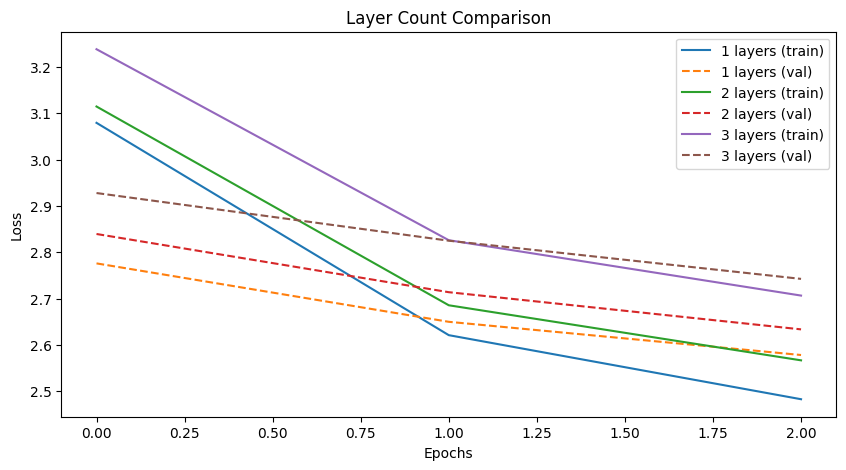

In [12]:


# Example of comparing layer performance (uncomment to use):
layer_configs = [1,2,3] # Example number of layers to test
trainer.compare_layer_performance(layer_configs, train_loader, val_loader, num_epochs=3) # reduced num_epochs for faster testing


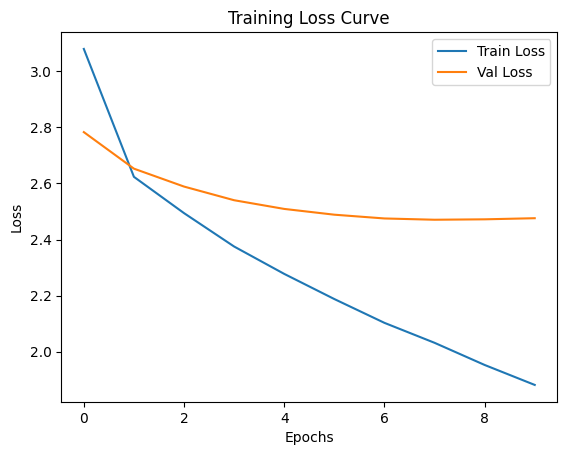

In [17]:
# Plot training curve
plt.plot(trainer.train_losses, label='Train Loss') # Changed train_loss to trainer.train_losses
plt.plot(trainer.val_losses, label='Val Loss')   # Changed val_loss to trainer.val_losses
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend() # Added legend to display labels
plt.show()

In [20]:
# prompt: write a code to plot the vanising gradient analysis of training

import matplotlib.pyplot as plt
import numpy as np
def plot_gradients(self):
        """Enhanced gradient analysis with vanishing/exploding detection"""
        plt.figure(figsize=(10,5))
        plt.plot(self.gradient_norms)
        plt.title('Gradient Norms During Training')
        plt.xlabel('Training Steps')
        plt.ylabel('Gradient Norm')

        # Detect vanishing/exploding gradients
        vanishing_steps = np.where(np.array(self.gradient_norms) < 1e-3)[0]
        exploding_steps = np.where(np.array(self.gradient_norms) > 1e3)[0]

        if len(vanishing_steps) > 0:
            plt.scatter(vanishing_steps, np.array(self.gradient_norms)[vanishing_steps],
                       color='red', label='Vanishing Gradients')
        if len(exploding_steps) > 0:
            plt.scatter(exploding_steps, np.array(self.gradient_norms)[exploding_steps],
                       color='orange', label='Exploding Gradients')

        plt.legend()
        plt.show()

        print(f"Vanishing gradients detected at steps: {vanishing_steps}")
        print(f"Exploding gradients detected at steps: {exploding_steps}")
